# Card 9 — Classificação das letras A, B e C

**Autor:** Pither Mikael Gonçalves Duarte

Classificação de imagens sintéticas utilizando TensorFlow.

In [36]:
import tensorflow as tf

print("TensorFlow funcionando.")
print("Versão:", tf.__version__)

TensorFlow funcionando.
Versão: 2.20.0


In [37]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
from pathlib import Path

DATASET_DIR = Path(
    "/content/drive/MyDrive/Fastcamp/Card_09/dataset"
)

print("Caminho:", DATASET_DIR)
print("Pasta encontrada:", DATASET_DIR.exists())

Caminho: /content/drive/MyDrive/Fastcamp/Card_09/dataset
Pasta encontrada: True


In [39]:
import math
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path

DATASET_DIR = Path(
    "/content/drive/MyDrive/Fastcamp/Card_09/dataset"
)

if not DATASET_DIR.is_dir():
    raise FileNotFoundError(
        f"Dataset não encontrado em: {DATASET_DIR}"
    )

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

tf.keras.utils.set_random_seed(SEED)

SPLITS = ["train", "val", "test"]
EXTENSOES = {".png", ".jpg", ".jpeg", ".bmp"}

contagens = {}
classes_por_divisao = {}

for divisao in SPLITS:
    pasta_divisao = DATASET_DIR / divisao

    if not pasta_divisao.is_dir():
        raise FileNotFoundError(
            f'A pasta "{divisao}" não foi encontrada em {DATASET_DIR}'
        )

    pastas_classes = sorted(
        pasta
        for pasta in pasta_divisao.iterdir()
        if pasta.is_dir()
    )

    if not pastas_classes:
        raise ValueError(
            f'Nenhuma classe foi encontrada na pasta "{divisao}".'
        )

    classes_por_divisao[divisao] = [
        pasta.name for pasta in pastas_classes
    ]

    contagens[divisao] = {}

    for pasta_classe in pastas_classes:
        quantidade = sum(
            1
            for arquivo in pasta_classe.rglob("*")
            if arquivo.is_file()
            and arquivo.suffix.lower() in EXTENSOES
        )

        contagens[divisao][pasta_classe.name] = quantidade

classes_esperadas = classes_por_divisao["train"]

for divisao in SPLITS:
    if classes_por_divisao[divisao] != classes_esperadas:
        raise ValueError(
            f"As classes de {divisao} são diferentes das classes de treino."
        )

print("TensorFlow:", tf.__version__)
print("Dataset:", DATASET_DIR)
print("Classes encontradas:", classes_esperadas)

for divisao in SPLITS:
    print(f"\n{divisao.upper()}")

    for classe, quantidade in contagens[divisao].items():
        print(f"{classe}: {quantidade} imagens")

menor_classe_treino = min(contagens["train"].values())

if menor_classe_treino < 20:
    print(
        "\nAVISO: o dataset possui poucas imagens de treino."
        "\nO código funcionará, mas a acurácia não será confiável."
    )

TensorFlow: 2.20.0
Dataset: /content/drive/MyDrive/Fastcamp/Card_09/dataset
Classes encontradas: ['A', 'B', 'C']

TRAIN
A: 300 imagens
B: 300 imagens
C: 300 imagens

VAL
A: 80 imagens
B: 80 imagens
C: 80 imagens

TEST
A: 10 imagens
B: 10 imagens
C: 10 imagens


In [40]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(DATASET_DIR / "train"),
    labels="inferred",
    label_mode="int",
    class_names=classes_esperadas,
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    str(DATASET_DIR / "val"),
    labels="inferred",
    label_mode="int",
    class_names=classes_esperadas,
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    str(DATASET_DIR / "test"),
    labels="inferred",
    label_mode="int",
    class_names=classes_esperadas,
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nClasses carregadas:", class_names)
print("Número de classes:", num_classes)

Found 900 files belonging to 3 classes.
Found 240 files belonging to 3 classes.
Found 30 files belonging to 3 classes.

Classes carregadas: ['A', 'B', 'C']
Número de classes: 3


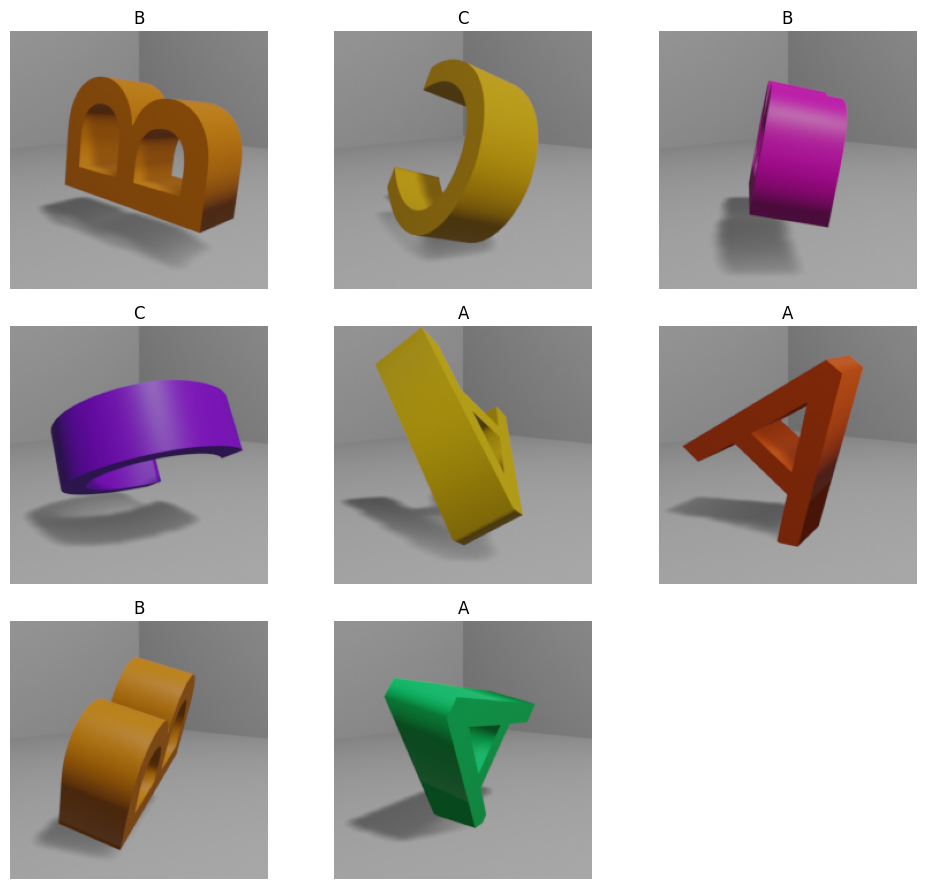

In [41]:
imagens, rotulos = next(iter(train_ds))

quantidade = min(9, int(imagens.shape[0]))
colunas = 3
linhas = math.ceil(quantidade / colunas)

plt.figure(figsize=(10, 3 * linhas))

for indice in range(quantidade):
    plt.subplot(linhas, colunas, indice + 1)

    imagem = imagens[indice].numpy().astype("uint8")
    rotulo = int(rotulos[indice].numpy())

    plt.imshow(imagem)
    plt.title(class_names[rotulo])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Datasets preparados.")

Datasets preparados.


In [43]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=IMG_SIZE + (3,),
    name="imagem"
)

x = tf.keras.layers.Rescaling(
    scale=1.0 / 127.5,
    offset=-1,
    name="normalizacao"
)(inputs)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="media_global"
)(x)

x = tf.keras.layers.Dropout(
    0.2,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    num_classes,
    activation="softmax",
    name="classificacao"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="classificador_abc"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "classificador_abc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagem (InputLayer)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacao (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ media_global                    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classificacao (Dense)           │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [44]:
OUTPUT_DIR = DATASET_DIR.parent / "resultados_abc"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 4

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/4
113/113 ━━━━━━━━━━━━━━━━━━━━ 412s 4s/step - accuracy: 0.7656 - loss: 0.5359 - val_accuracy: 0.9083 - val_loss: 0.2593
Epoch 2/4
113/113 ━━━━━━━━━━━━━━━━━━━━ 45s 399ms/step - accuracy: 0.9133 - loss: 0.2365 - val_accuracy: 0.9208 - val_loss: 0.1954
Epoch 3/4
113/113 ━━━━━━━━━━━━━━━━━━━━ 46s 404ms/step - accuracy: 0.9389 - loss: 0.1756 - val_accuracy: 0.9333 - val_loss: 0.1668
Epoch 4/4
113/113 ━━━━━━━━━━━━━━━━━━━━ 46s 402ms/step - accuracy: 0.9500 - loss: 0.1439 - val_accuracy: 0.9542 - val_loss: 0.1480


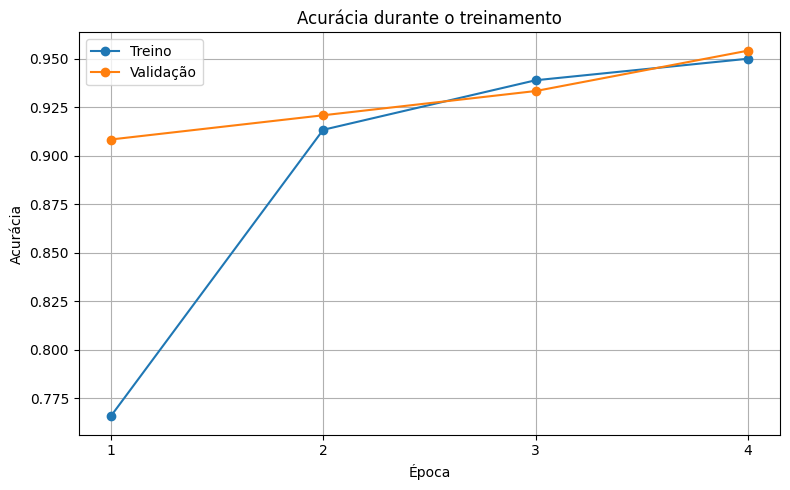

In [45]:
epocas = range(
    1,
    len(history.history["accuracy"]) + 1
)

fig = plt.figure(figsize=(8, 5))

plt.plot(
    epocas,
    history.history["accuracy"],
    marker="o",
    label="Treino"
)

plt.plot(
    epocas,
    history.history["val_accuracy"],
    marker="o",
    label="Validação"
)

plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.xticks(list(epocas))
plt.legend()
plt.grid(True)
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "acuracia_abc.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

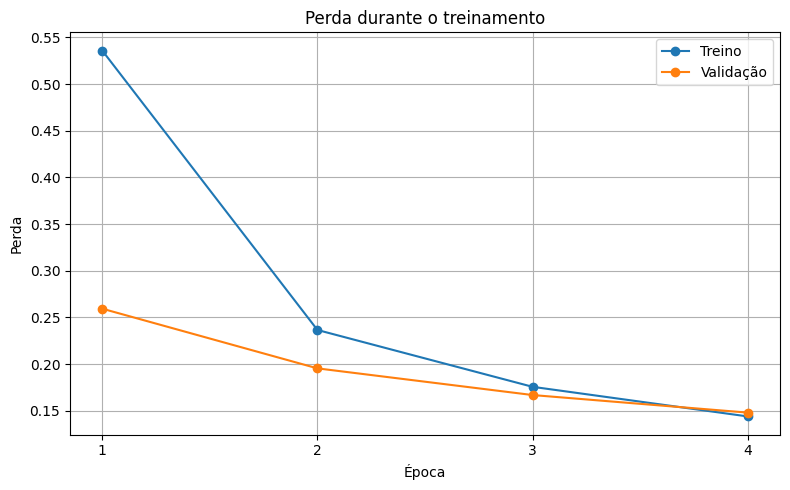

In [46]:
fig = plt.figure(figsize=(8, 5))

plt.plot(
    epocas,
    history.history["loss"],
    marker="o",
    label="Treino"
)

plt.plot(
    epocas,
    history.history["val_loss"],
    marker="o",
    label="Validação"
)

plt.title("Perda durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.xticks(list(epocas))
plt.legend()
plt.grid(True)
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "perda_abc.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [47]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nPerda no teste: {test_loss:.4f}")
print(f"Acurácia no teste: {test_accuracy:.2%}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.9333 - loss: 0.2400

Perda no teste: 0.2400
Acurácia no teste: 93.33%


In [48]:
lista_imagens = []
lista_rotulos = []
lista_probabilidades = []

for lote_imagens, lote_rotulos in test_ds:
    probabilidades = model.predict(
        lote_imagens,
        verbose=0
    )

    lista_imagens.append(
        lote_imagens.numpy()
    )

    lista_rotulos.append(
        lote_rotulos.numpy()
    )

    lista_probabilidades.append(
        probabilidades
    )

test_images = np.concatenate(
    lista_imagens,
    axis=0
)

true_labels = np.concatenate(
    lista_rotulos,
    axis=0
)

predicted_probabilities = np.concatenate(
    lista_probabilidades,
    axis=0
)

predicted_labels = np.argmax(
    predicted_probabilities,
    axis=1
)

confidence_scores = np.max(
    predicted_probabilities,
    axis=1
)

print("Quantidade de previsões:", len(predicted_labels))

Quantidade de previsões: 30


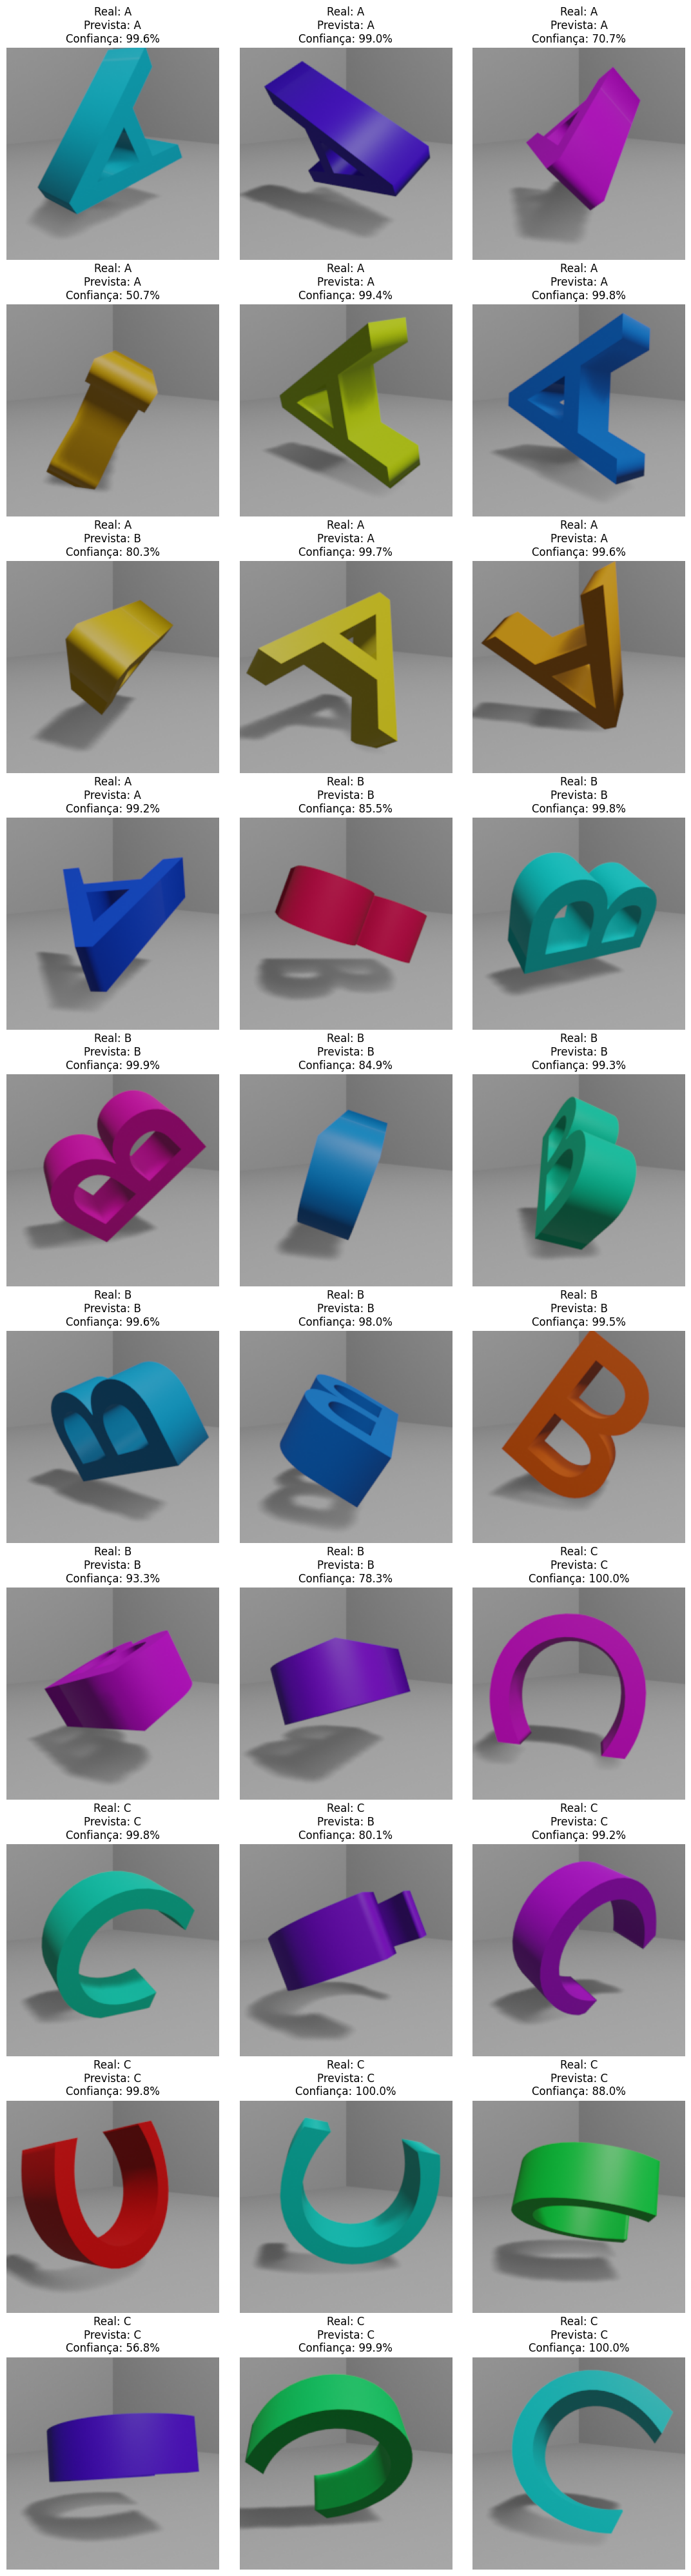

In [49]:
quantidade = len(test_images)
colunas = 3
linhas = math.ceil(quantidade / colunas)

fig = plt.figure(
    figsize=(11, 4 * linhas)
)

for indice in range(quantidade):
    plt.subplot(
        linhas,
        colunas,
        indice + 1
    )

    imagem = np.clip(
        test_images[indice],
        0,
        255
    ).astype("uint8")

    classe_real = class_names[
        int(true_labels[indice])
    ]

    classe_prevista = class_names[
        int(predicted_labels[indice])
    ]

    confianca = confidence_scores[indice]

    plt.imshow(imagem)

    plt.title(
        f"Real: {classe_real}\n"
        f"Prevista: {classe_prevista}\n"
        f"Confiança: {confianca:.1%}"
    )

    plt.axis("off")

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "previsoes_abc.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

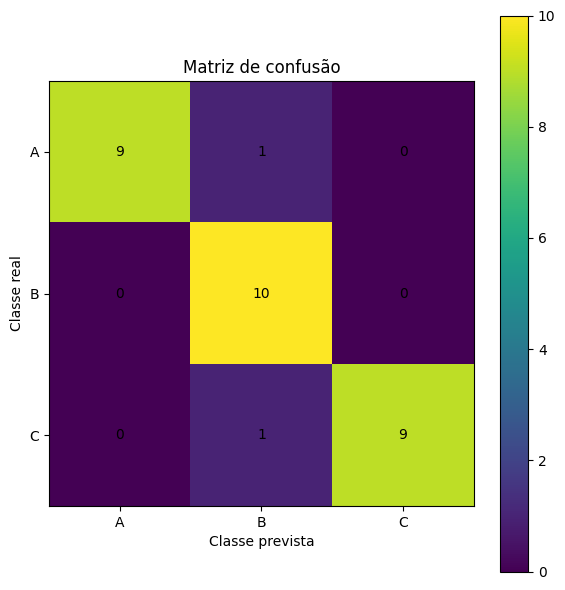

[[ 9  1  0]
 [ 0 10  0]
 [ 0  1  9]]


In [50]:
matriz = tf.math.confusion_matrix(
    true_labels,
    predicted_labels,
    num_classes=num_classes
).numpy()

fig, ax = plt.subplots(
    figsize=(6, 6)
)

imagem_matriz = ax.imshow(matriz)

ax.set_title("Matriz de confusão")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

ax.set_xticks(
    range(num_classes)
)

ax.set_yticks(
    range(num_classes)
)

ax.set_xticklabels(
    class_names
)

ax.set_yticklabels(
    class_names
)

for linha in range(num_classes):
    for coluna in range(num_classes):
        ax.text(
            coluna,
            linha,
            str(matriz[linha, coluna]),
            ha="center",
            va="center"
        )

fig.colorbar(
    imagem_matriz,
    ax=ax
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "matriz_confusao_abc.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(matriz)

In [51]:
MODEL_PATH = OUTPUT_DIR / "classificador_abc_aula.keras"

model.save(
    str(MODEL_PATH)
)

historico_convertido = {
    chave: [
        float(valor)
        for valor in valores
    ]
    for chave, valores in history.history.items()
}

with open(
    OUTPUT_DIR / "historico_treinamento.json",
    "w",
    encoding="utf-8"
) as arquivo:
    json.dump(
        historico_convertido,
        arquivo,
        indent=2,
        ensure_ascii=False
    )

metadados = {
    "classes": class_names,
    "tamanho_imagem": list(IMG_SIZE),
    "epocas": EPOCHS,
    "tensorflow": tf.__version__,
    "perda_teste": float(test_loss),
    "acuracia_teste": float(test_accuracy)
}

with open(
    OUTPUT_DIR / "metadados.json",
    "w",
    encoding="utf-8"
) as arquivo:
    json.dump(
        metadados,
        arquivo,
        indent=2,
        ensure_ascii=False
    )

with open(
    OUTPUT_DIR / "classes.txt",
    "w",
    encoding="utf-8"
) as arquivo:
    arquivo.write(
        "\n".join(class_names)
    )

print("Modelo salvo em:")
print(MODEL_PATH)

print("\nArquivos salvos em:")
print(OUTPUT_DIR)

Modelo salvo em:
/content/drive/MyDrive/Fastcamp/Card_09/resultados_abc/classificador_abc_aula.keras

Arquivos salvos em:
/content/drive/MyDrive/Fastcamp/Card_09/resultados_abc


In [52]:
modelo_carregado = tf.keras.models.load_model(
    str(MODEL_PATH)
)

perda_carregada, acuracia_carregada = modelo_carregado.evaluate(
    test_ds,
    verbose=0
)

print("Modelo carregado corretamente.")
print(f"Acurácia após recarregar: {acuracia_carregada:.2%}")

Modelo carregado corretamente.
Acurácia após recarregar: 93.33%
